### **Installations and Imports**

In [1]:
import importlib.util
import subprocess
import sys

def is_installed(import_name):
    return importlib.util.find_spec(import_name) is not None

# package_name_on_pip : import_name_in_python
required = {
    "unsloth": "unsloth",
    "unsloth_zoo": "unsloth_zoo",
    "trl": "trl",
    "bitsandbytes": "bitsandbytes",
    "sacrebleu": "sacrebleu",
    "evaluate": "evaluate",
}

missing = [
    pip_name
    for pip_name, import_name in required.items()
    if not is_installed(import_name)
]

print("Missing packages:", missing)

if missing:
    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--no-cache-dir",
        *missing,
    ]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)
else:
    print("All required extra packages are already installed.")

print("Minimal installation finished.")

Missing packages: ['unsloth', 'unsloth_zoo', 'trl', 'bitsandbytes', 'sacrebleu', 'evaluate']
Running: /usr/bin/python3 -m pip install -q --no-cache-dir unsloth unsloth_zoo trl bitsandbytes sacrebleu evaluate
Minimal installation finished.


In [2]:
# ============================================================
# Cell 1B — Verify environment
# ============================================================

import torch
import datasets
import transformers
import peft
import accelerate
import trl
import unsloth
import bitsandbytes
import sacrebleu

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: CUDA is not available.")
    print("Do not start Qwen/Unsloth fine-tuning on CPU.")
    print("Go to Runtime → Change runtime type → GPU.")

print("datasets:", datasets.__version__)
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)
print("trl:", trl.__version__)
print("sacrebleu:", sacrebleu.__version__)

print("Environment check finished.")

/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:144: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
datasets: 4.3.0
transformers: 5.5.0
peft: 0.19.1
accelerate: 1.13.0
trl: 0.24.0
sacrebleu: 2.6.0
Environment check finished.


### **Paths and Configurations**

In [3]:
# ============================================================
# Cell 2 — Mount Google Drive and define paths
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/alexandria_qwen35_sft")
DATA_DIR    = PROJECT_DIR / "prepared_data"
RUNS_DIR    = PROJECT_DIR / "runs"
ADAPTER_DIR = PROJECT_DIR / "final_adapters"
PRED_DIR    = PROJECT_DIR / "predictions"

for p in [PROJECT_DIR, DATA_DIR, RUNS_DIR, ADAPTER_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("ADAPTER_DIR:", ADAPTER_DIR)
print("PRED_DIR:", PRED_DIR)

Mounted at /content/drive
PROJECT_DIR: /content/drive/MyDrive/alexandria_qwen35_sft
DATA_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/prepared_data
RUNS_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/runs
ADAPTER_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/final_adapters
PRED_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/predictions


In [4]:
# ============================================================
# Cell 3 — Experiment configuration
# Experiment 5: ALL group, r=8, 10 epochs, keep checkpoints
# ============================================================

import torch
import random
import numpy as np

SEED = 3407
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

MODEL_NAME = "unsloth/Qwen3.5-2B-Base"

# ------------------------------------------------------------
# Country/config selection
# Keep same data setup as previous experiments
# ------------------------------------------------------------

SELECTED_CONFIGS_MODE = "EG_ONLY"   # "EG_ONLY" or "ALL" or "MANUAL"
MANUAL_CONFIGS = ["EG"]

# ------------------------------------------------------------
# Translation setup
# Keep same preprocessing/context setup
# ------------------------------------------------------------

MAX_CONTEXT_TURNS = 3
USE_PREVIOUS_ENGLISH_CONTEXT = True
USE_METADATA = True

# ------------------------------------------------------------
# LoRA mode
# ------------------------------------------------------------
# "attn" = q_proj, k_proj, v_proj, o_proj
# "mlp"  = FNN / feed-forward group: gate_proj, up_proj, down_proj
# "all"  = attention + FNN / MLP

LORA_MODE = "all"

# ------------------------------------------------------------
# LoRA rank settings
# ------------------------------------------------------------

LORA_R = 8
LORA_ALPHA = 16   # keep alpha = 2 * r

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

NUM_EPOCHS = 10
MAX_SEQ_LENGTH = 768

PER_DEVICE_BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 8

LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.03

SAVE_STEPS = 200
EVAL_STEPS = 200
LOGGING_STEPS = 10

PACKING = False

# Important:
# Keep enough checkpoints so checkpoint-1000 is not deleted again.
SAVE_TOTAL_LIMIT = 20

# ------------------------------------------------------------
# Experiment naming
# Safe new folder/files, no overwrite of previous experiments
# ------------------------------------------------------------

if LORA_MODE == "attn":
    LORA_GROUP_NAME = "attn_group"
elif LORA_MODE == "mlp":
    LORA_GROUP_NAME = "fnn_group"
elif LORA_MODE == "all":
    LORA_GROUP_NAME = "all_group"
else:
    raise ValueError("LORA_MODE must be 'attn', 'mlp', or 'all'.")

EXPERIMENT_NAME = (
    f"qwen35_2b_alexandria_{SELECTED_CONFIGS_MODE.lower()}_"
    f"context{MAX_CONTEXT_TURNS}_{LORA_GROUP_NAME}_r{LORA_R}_10epochs"
)

OUTPUT_DIR = RUNS_DIR / EXPERIMENT_NAME
FINAL_ADAPTER_PATH = ADAPTER_DIR / EXPERIMENT_NAME

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Experiment:", EXPERIMENT_NAME)
print("LoRA mode:", LORA_MODE)
print("LoRA r:", LORA_R)
print("LoRA alpha:", LORA_ALPHA)
print("Save total limit:", SAVE_TOTAL_LIMIT)
print("Output dir:", OUTPUT_DIR)
print("Final adapter:", FINAL_ADAPTER_PATH)

Model: unsloth/Qwen3.5-2B-Base
Experiment: qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs
LoRA mode: all
LoRA r: 8
LoRA alpha: 16
Save total limit: 20
Output dir: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs
Final adapter: /content/drive/MyDrive/alexandria_qwen35_sft/final_adapters/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs


### **Dataset Preparation**

In [5]:
# ============================================================
# Cell 4 — List Alexandria configs and load selected configs
# ============================================================

from datasets import load_dataset, get_dataset_config_names
import pandas as pd

DATASET_NAME = "UBC-NLP/alexandria"

available_configs = get_dataset_config_names(DATASET_NAME)
print("Available Alexandria configs:")
print(available_configs)

if SELECTED_CONFIGS_MODE == "EG_ONLY":
    selected_configs = ["EG"] if "EG" in available_configs else [available_configs[0]]

elif SELECTED_CONFIGS_MODE == "ALL":
    selected_configs = available_configs

elif SELECTED_CONFIGS_MODE == "MANUAL":
    selected_configs = MANUAL_CONFIGS
    missing = [c for c in selected_configs if c not in available_configs]
    if missing:
        raise ValueError(f"These configs are not available: {missing}")

else:
    raise ValueError("SELECTED_CONFIGS_MODE must be EG_ONLY, ALL, or MANUAL.")

print("\nSelected configs:")
print(selected_configs)

loaded = {}

for cfg in selected_configs:
    print(f"\nLoading config: {cfg}")
    ds_train = load_dataset(DATASET_NAME, name=cfg, split="train")
    ds_test  = load_dataset(DATASET_NAME, name=cfg, split="test")

    loaded[cfg] = {
        "train": ds_train,
        "test": ds_test,
    }

    print("Train:", ds_train)
    print("Test:", ds_test)
    print("Example keys:", ds_train[0].keys())

README.md: 0.00B [00:00, ?B/s]

Available Alexandria configs:
['EG', 'JO', 'LB', 'LY', 'MA', 'MR', 'OM', 'PS', 'SA', 'SD', 'SY', 'TN', 'YE']

Selected configs:
['EG']

Loading config: EG


EG/train-00000-of-00001.parquet:   0%|          | 0.00/496k [00:00<?, ?B/s]

EG/test-00000-of-00001.parquet:   0%|          | 0.00/196k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/982 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/366 [00:00<?, ? examples/s]

Train: Dataset({
    features: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'],
    num_rows: 982
})
Test: Dataset({
    features: ['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'],
    num_rows: 366
})
Example keys: dict_keys(['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'])


In [6]:
# ============================================================
# Cell 5 — Inspect one raw example
# ============================================================

sample_cfg = selected_configs[0]
sample_row = loaded[sample_cfg]["train"][0]

print("Config:", sample_cfg)
print("Keys:", sample_row.keys())

print("\nEnglish conversation:")
print(sample_row["english_conversation"])

print("\nDialectal conversation:")
print(sample_row["dialectal_conversation"])

print("\nFull row:")
sample_row

Config: EG
Keys: dict_keys(['conv_id', 'country', 'domain', 'dialect', 'participants', 'english_conversation', 'dialectal_conversation', 'translator_id', 'reviewer_id'])

English conversation:
[{'direction': 'male -> female', 'speaker': 'Wholesale Buyer', 'text': "Good morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section, is that right?", 'turn_order': 1}, {'direction': 'female -> male', 'speaker': 'Wholesale Seller', 'text': "Good morning to you. You heard correctly. My artichokes are the best you'll find. They are top-grade, perfect for export. Let me show you a sample.", 'turn_order': 2}, {'direction': 'male -> female', 'speaker': 'Wholesale Buyer', 'text': 'Excellent. Yes, please show me. I need them to be a specific size and completely free of blemishes.', 'turn_order': 3}, {'direction': 'female -> male', 'speaker': 'Wholesale Seller', 'text': "Don't you worry. You will be very satisfied. My reputatio

{'conv_id': 'B7-1-0-120',
 'country': 'EG',
 'domain': 'Agriculture and farming',
 'dialect': 'Egyptian Arabic (Cairene) Dialect',
 'participants': 'Wholesale Buyer, Wholesale Seller',
 'english_conversation': [{'direction': 'male -> female',
   'speaker': 'Wholesale Buyer',
   'text': "Good morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section, is that right?",
   'turn_order': 1},
  {'direction': 'female -> male',
   'speaker': 'Wholesale Seller',
   'text': "Good morning to you. You heard correctly. My artichokes are the best you'll find. They are top-grade, perfect for export. Let me show you a sample.",
   'turn_order': 2},
  {'direction': 'male -> female',
   'speaker': 'Wholesale Buyer',
   'text': 'Excellent. Yes, please show me. I need them to be a specific size and completely free of blemishes.',
   'turn_order': 3},
  {'direction': 'female -> male',
   'speaker': 'Wholesale Seller',
   'text': "D

#### Helper functions for robust extraction

In [7]:
# ============================================================
# Cell 6 — Helper functions for robust extraction
# ============================================================

def safe_get(row, keys, default=""):
    for k in keys:
        if isinstance(row, dict) and k in row and row[k] is not None:
            return row[k]
    return default

def turn_text(turn):
    if isinstance(turn, dict):
        for k in ["text", "sentence", "utterance", "content", "value"]:
            if k in turn and turn[k] is not None:
                return str(turn[k]).strip()
        return str(turn).strip()
    return str(turn).strip()

def turn_field(turn, keys, default=""):
    if isinstance(turn, dict):
        for k in keys:
            if k in turn and turn[k] is not None:
                return str(turn[k]).strip()
    return default

def normalize_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    return list(x)

def truncate_text(text, max_chars=1200):
    text = str(text)
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rstrip() + " ..."

#### Flatten Alexandria conversations into SFT examples and Save

In [8]:
# ============================================================
# Cell 7 — Flatten Alexandria conversations
# ============================================================

def flatten_alexandria_split(ds, cfg_name, split_name, max_context_turns=3):
    records = []

    for conv_idx, row in enumerate(ds):
        english_conv = normalize_list(row["english_conversation"])
        dialect_conv = normalize_list(row["dialectal_conversation"])

        n = min(len(english_conv), len(dialect_conv))

        country = safe_get(row, ["country", "country_code"], cfg_name)
        dialect = safe_get(row, ["dialect", "dialect_label", "subdialect", "city", "variety"], "")
        domain = safe_get(row, ["domain", "topic"], "")
        persona = safe_get(row, ["persona", "roles", "speaker_roles"], "")
        conv_id = safe_get(row, ["conversation_id", "id", "dialogue_id"], f"{cfg_name}_{split_name}_{conv_idx}")

        for i in range(n):
            en_turn = english_conv[i]
            ar_turn = dialect_conv[i]

            source_text = turn_text(en_turn)
            target_text = turn_text(ar_turn)

            if not source_text or not target_text:
                continue

            prev_start = max(0, i - max_context_turns)
            prev_en_turns = english_conv[prev_start:i]

            previous_context = []
            for j, t in enumerate(prev_en_turns, start=prev_start):
                previous_context.append({
                    "turn_id": j,
                    "speaker": turn_field(t, ["speaker", "role", "speaker_role"], ""),
                    "direction": turn_field(t, ["direction", "gender_direction", "speaker_addressee_gender"], ""),
                    "text": turn_text(t),
                })

            records.append({
                "source_id": f"{cfg_name}_{split_name}_{conv_id}_{i}",
                "config": cfg_name,
                "split": split_name,
                "conversation_id": conv_id,
                "turn_id": i,

                "country": country,
                "dialect": dialect,
                "domain": domain,
                "persona": persona,

                "speaker": turn_field(en_turn, ["speaker", "role", "speaker_role"], ""),
                "gender_direction": turn_field(en_turn, ["direction", "gender_direction", "speaker_addressee_gender"], ""),

                "previous_english_turns": previous_context,
                "source_text": source_text,
                "target_arabic": target_text,
            })

    return records

train_records = []
eval_records = []

for cfg in selected_configs:
    train_records.extend(
        flatten_alexandria_split(
            loaded[cfg]["train"],
            cfg_name=cfg,
            split_name="train",
            max_context_turns=MAX_CONTEXT_TURNS,
        )
    )

    eval_records.extend(
        flatten_alexandria_split(
            loaded[cfg]["test"],
            cfg_name=cfg,
            split_name="test",
            max_context_turns=MAX_CONTEXT_TURNS,
        )
    )

train_df = pd.DataFrame(train_records)
eval_df = pd.DataFrame(eval_records)

print("Train shape:", train_df.shape)
print("Eval shape:", eval_df.shape)

print("\nTrain configs:")
print(train_df["config"].value_counts())

print("\nEval configs:")
print(eval_df["config"].value_counts())

display(train_df.head())

Train shape: (3108, 14)
Eval shape: (1118, 14)

Train configs:
config
EG    3108
Name: count, dtype: int64

Eval configs:
config
EG    1118
Name: count, dtype: int64


,source_id,config,split,conversation_id,turn_id,country,dialect,domain,persona,speaker,gender_direction,previous_english_turns,source_text,target_arabic
0,EG_train_EG_train_0_0,EG,train,EG_train_0,0,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Buyer,male -> female,[],Good morning. I'm looking to source 10 tons of...,صباح الخير، عايز عشرة طن من الخرشوف الكويس للت...
1,EG_train_EG_train_0_1,EG,train,EG_train_0,1,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Seller,female -> male,"[{'turn_id': 0, 'speaker': 'Wholesale Buyer', ...",Good morning to you. You heard correctly. My a...,صباح النور،سمعك مظبوط،الخرشوف بتاعي من أحسن ال...
2,EG_train_EG_train_0_2,EG,train,EG_train_0,2,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Buyer,male -> female,"[{'turn_id': 0, 'speaker': 'Wholesale Buyer', ...","Excellent. Yes, please show me. I need them to...",ممتاز، لو سمحتي وريني، عايزه بمقاس واحد ومافيه...
3,EG_train_EG_train_0_3,EG,train,EG_train_0,3,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Wholesale Seller,female -> male,"[{'turn_id': 0, 'speaker': 'Wholesale Buyer', ...",Don't you worry. You will be very satisfied. M...,متخافش، هتنبسط جدا، سمعتي جاية من الحاجة الكويسة.
4,EG_train_EG_train_1_0,EG,train,EG_train_1,0,EG,Egyptian Arabic (Cairene) Dialect,Agriculture and farming,,Farmer,female -> female,[],I usually use the regular granular fertilizer....,أنا عادة بستخدم السماد العادي الحبيبات. ايه فا...


In [9]:
# ============================================================
# Cell 8 — Save prepared flattened data
# ============================================================

train_jsonl = DATA_DIR / f"alexandria_train_{SELECTED_CONFIGS_MODE.lower()}_context{MAX_CONTEXT_TURNS}.jsonl"
eval_jsonl  = DATA_DIR / f"alexandria_eval_{SELECTED_CONFIGS_MODE.lower()}_context{MAX_CONTEXT_TURNS}.jsonl"

train_df.to_json(train_jsonl, orient="records", lines=True, force_ascii=False)
eval_df.to_json(eval_jsonl, orient="records", lines=True, force_ascii=False)

print("Saved train:", train_jsonl)
print("Saved eval:", eval_jsonl)

Saved train: /content/drive/MyDrive/alexandria_qwen35_sft/prepared_data/alexandria_train_eg_only_context3.jsonl
Saved eval: /content/drive/MyDrive/alexandria_qwen35_sft/prepared_data/alexandria_eval_eg_only_context3.jsonl


### **Build prompt and chat messages**

In [10]:
# ============================================================
# Cell 9 — Build prompt and chat messages
# ============================================================

from datasets import Dataset

SYSTEM_PROMPT = (
    "You are a professional machine translation system. "
    "Translate the current English dialogue turn into natural dialectal Arabic. "
    "Return only the translation, without explanation."
)

def build_context(previous_turns):
    if not USE_PREVIOUS_ENGLISH_CONTEXT or not previous_turns:
        return "No previous context."

    lines = []
    for i, t in enumerate(previous_turns, start=1):
        speaker = t.get("speaker", "")
        text = t.get("text", "")
        if speaker:
            lines.append(f"{i}. {speaker}: {text}")
        else:
            lines.append(f"{i}. {text}")

    return "\n".join(lines)

def build_metadata_block(row):
    if not USE_METADATA:
        return "No metadata."

    fields = [
        ("Country/config", row.get("config", "")),
        ("Target dialect", row.get("dialect", "")),
        ("Domain", row.get("domain", "")),
        ("Persona/Roles", row.get("persona", "")),
        ("Current speaker", row.get("speaker", "")),
        ("Speaker-to-addressee gender direction", row.get("gender_direction", "")),
    ]

    lines = []
    for k, v in fields:
        v = str(v).strip()
        if v:
            lines.append(f"{k}: {v}")

    return "\n".join(lines) if lines else "No metadata."

def make_user_prompt(row):
    context = build_context(row["previous_english_turns"])
    metadata = build_metadata_block(row)

    return f"""Task:
Translate the current English dialogue turn into the target dialectal Arabic variety.

Metadata:
{metadata}

Previous English dialogue context:
{context}

Current English turn:
{row["source_text"]}

Rules:
- Preserve the meaning exactly.
- Use natural local dialectal Arabic, not Modern Standard Arabic unless it is natural in context.
- Preserve names, numbers, named entities, and technical terms when appropriate.
- Keep the tone appropriate for the speaker and domain.
- Return only the Arabic translation."""

def row_to_messages(row):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": make_user_prompt(row)},
        {"role": "assistant", "content": row["target_arabic"]},
    ]

train_df["messages"] = train_df.apply(row_to_messages, axis=1)
eval_df["messages"]  = eval_df.apply(row_to_messages, axis=1)

train_dataset = Dataset.from_pandas(
    train_df[
        [
            "messages",
            "source_id",
            "config",
            "domain",
            "dialect",
            "source_text",
            "target_arabic",
        ]
    ],
    preserve_index=False,
)

eval_dataset = Dataset.from_pandas(
    eval_df[
        [
            "messages",
            "source_id",
            "config",
            "domain",
            "dialect",
            "source_text",
            "target_arabic",
        ]
    ],
    preserve_index=False,
)

print(train_dataset)
print(eval_dataset)

print("\nExample messages:")
train_dataset[0]["messages"]

Dataset({
    features: ['messages', 'source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic'],
    num_rows: 3108
})
Dataset({
    features: ['messages', 'source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic'],
    num_rows: 1118
})

Example messages:


[{'role': 'system',
  'content': 'You are a professional machine translation system. Translate the current English dialogue turn into natural dialectal Arabic. Return only the translation, without explanation.'},
 {'role': 'user',
  'content': "Task:\nTranslate the current English dialogue turn into the target dialectal Arabic variety.\n\nMetadata:\nCountry/config: EG\nTarget dialect: Egyptian Arabic (Cairene) Dialect\nDomain: Agriculture and farming\nCurrent speaker: Wholesale Buyer\nSpeaker-to-addressee gender direction: male -> female\n\nPrevious English dialogue context:\nNo previous context.\n\nCurrent English turn:\nGood morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section, is that right?\n\nRules:\n- Preserve the meaning exactly.\n- Use natural local dialectal Arabic, not Modern Standard Arabic unless it is natural in context.\n- Preserve names, numbers, named entities, and technical terms when appr

### **Load Qwen3.5-2B with Unsloth**

In [11]:
# ============================================================
# UPDATED Cell 10 — Load Qwen3.5-2B with Unsloth
# Prefer FastLanguageModel for text-only SFT
# ============================================================

import torch

try:
    from unsloth import FastLanguageModel
    UnslothModel = FastLanguageModel
    print("Using unsloth.FastLanguageModel")
except Exception:
    from unsloth import FastModel
    UnslothModel = FastModel
    print("Using unsloth.FastModel fallback")

dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

model, tokenizer = UnslothModel.from_pretrained(
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = dtype,
    load_in_4bit = False,
)

# If Unsloth returns a processor-like object, extract the real tokenizer if available.
if hasattr(tokenizer, "tokenizer"):
    print("Tokenizer object has internal tokenizer. Using tokenizer.tokenizer.")
    tokenizer = tokenizer.tokenizer

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded:", MODEL_NAME)
print("dtype:", dtype)
print("Tokenizer type:", type(tokenizer))
print("pad token:", tokenizer.pad_token)
print("eos token:", tokenizer.eos_token)

Using unsloth.FastLanguageModel
==((====))==  Unsloth 2026.5.6: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


model.safetensors:   0%|          | 0.00/4.43G [00:00<?, ?B/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/617 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/146 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

Tokenizer object has internal tokenizer. Using tokenizer.tokenizer.
Loaded: unsloth/Qwen3.5-2B-Base
dtype: torch.float16
Tokenizer type: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>
pad token: <|vision_pad|>
eos token: <|endoftext|>


### **Apply Chat Template**

In [12]:
# ============================================================
# UPDATED Cell 11 — Manual SFT template
# Do NOT use tokenizer.apply_chat_template
# ============================================================

SYSTEM_MARKER = "### System:"
INSTRUCTION_MARKER = "### Instruction:"
RESPONSE_MARKER = "### Arabic translation:"

def get_message_content(messages, role):
    for m in messages:
        if m.get("role") == role:
            return m.get("content", "")
    return ""

def format_sft_text(system_text, user_text, assistant_text=None, add_eos=True):
    """
    Manual decoder-only SFT format.

    During training:
        prompt + assistant answer + EOS

    During inference:
        prompt only, ending at RESPONSE_MARKER
    """

    text = (
        f"{SYSTEM_MARKER}\n"
        f"{system_text.strip()}\n\n"
        f"{INSTRUCTION_MARKER}\n"
        f"{user_text.strip()}\n\n"
        f"{RESPONSE_MARKER}\n"
    )

    if assistant_text is not None:
        text += assistant_text.strip()

        if add_eos and tokenizer.eos_token is not None:
            text += tokenizer.eos_token

    return text

def apply_manual_sft_template(example):
    messages = example["messages"]

    system_text = get_message_content(messages, "system")
    user_text = get_message_content(messages, "user")
    assistant_text = get_message_content(messages, "assistant")

    text = format_sft_text(
        system_text=system_text,
        user_text=user_text,
        assistant_text=assistant_text,
        add_eos=True,
    )

    return {"text": text}

remove_cols_train = [c for c in train_dataset.column_names if c == "messages"]
remove_cols_eval  = [c for c in eval_dataset.column_names if c == "messages"]

train_dataset_text = train_dataset.map(
    apply_manual_sft_template,
    remove_columns=remove_cols_train,
)

eval_dataset_text = eval_dataset.map(
    apply_manual_sft_template,
    remove_columns=remove_cols_eval,
)

print(train_dataset_text)
print(eval_dataset_text)

print("\nFormatted example:")
print(train_dataset_text[0]["text"])

Map:   0%|          | 0/3108 [00:00<?, ? examples/s]

Map:   0%|          | 0/1118 [00:00<?, ? examples/s]

Dataset({
    features: ['source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic', 'text'],
    num_rows: 3108
})
Dataset({
    features: ['source_id', 'config', 'domain', 'dialect', 'source_text', 'target_arabic', 'text'],
    num_rows: 1118
})

Formatted example:
### System:
You are a professional machine translation system. Translate the current English dialogue turn into natural dialectal Arabic. Return only the translation, without explanation.

### Instruction:
Task:
Translate the current English dialogue turn into the target dialectal Arabic variety.

Metadata:
Country/config: EG
Target dialect: Egyptian Arabic (Cairene) Dialect
Domain: Agriculture and farming
Current speaker: Wholesale Buyer
Speaker-to-addressee gender direction: male -> female

Previous English dialogue context:
No previous context.

Current English turn:
Good morning. I'm looking to source 10 tons of premium artichokes for export. People say the best quality in Obour comes from your section,

#### **Configure LoRA target modules**

In [13]:
# ============================================================
# Cell 12 — Configure LoRA
# Uses LORA_R and LORA_ALPHA from Cell 3
# ============================================================

if LORA_MODE == "attn":
    TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]

elif LORA_MODE == "mlp":
    TARGET_MODULES = ["gate_proj", "up_proj", "down_proj"]

elif LORA_MODE == "all":
    TARGET_MODULES = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ]

else:
    raise ValueError("LORA_MODE must be 'attn', 'mlp', or 'all'.")

print("Target modules:", TARGET_MODULES)
print("LoRA r:", LORA_R)
print("LoRA alpha:", LORA_ALPHA)

model = UnslothModel.get_peft_model(
    model,
    r = LORA_R,
    target_modules = TARGET_MODULES,
    lora_alpha = LORA_ALPHA,
    lora_dropout = 0.05,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = SEED,
    max_seq_length = MAX_SEQ_LENGTH,
)

model.print_trainable_parameters()

Target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']
LoRA r: 8
LoRA alpha: 16


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


trainable params: 5,455,872 || all params: 2,218,697,536 || trainable%: 0.2459


#### Check for existing checkpoints

In [14]:
# ============================================================
# Cell 13 — Check for existing checkpoints
# ============================================================

from transformers.trainer_utils import get_last_checkpoint

last_checkpoint = None

if OUTPUT_DIR.exists():
    last_checkpoint = get_last_checkpoint(str(OUTPUT_DIR))

if last_checkpoint:
    print("Found checkpoint:")
    print(last_checkpoint)
else:
    print("No checkpoint found. Training will start from scratch.")

Found checkpoint:
/content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs/checkpoint-1600


### **Build SFTTrainer**

In [15]:
# ============================================================
# Cell 14 — Build SFTTrainer
# ============================================================

from trl import SFTTrainer, SFTConfig

sft_args = SFTConfig(
    output_dir = str(OUTPUT_DIR),

    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size = 1,
    gradient_accumulation_steps = GRAD_ACCUM_STEPS,

    learning_rate = LEARNING_RATE,
    warmup_ratio = WARMUP_RATIO,
    lr_scheduler_type = "cosine",

    optim = "adamw_8bit",
    weight_decay = 0.01,

    logging_steps = LOGGING_STEPS,

    eval_strategy = "steps",
    eval_steps = EVAL_STEPS,

    save_strategy = "steps",
    save_steps = SAVE_STEPS,
    save_total_limit = SAVE_TOTAL_LIMIT,

    fp16 = not torch.cuda.is_bf16_supported(),
    bf16 = torch.cuda.is_bf16_supported(),

    seed = SEED,
    dataset_num_proc = 2,
    report_to = "none",

    packing = PACKING,
    dataset_text_field = "text",
    max_length = MAX_SEQ_LENGTH,
)

try:
    trainer = SFTTrainer(
        model = model,
        tokenizer = tokenizer,
        train_dataset = train_dataset_text,
        eval_dataset = eval_dataset_text,
        args = sft_args,
    )
except TypeError:
    trainer = SFTTrainer(
        model = model,
        processing_class = tokenizer,
        train_dataset = train_dataset_text,
        eval_dataset = eval_dataset_text,
        args = sft_args,
    )

print("Trainer ready.")
print("Output dir:", OUTPUT_DIR)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/3108 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1118 [00:00<?, ? examples/s]

Trainer ready.
Output dir: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs


#### Response-only training with manual markers

In [16]:
# ============================================================
# UPDATED Cell 15 — Train on assistant response only
# Uses manual markers from Cell 11
# ============================================================

try:
    from unsloth.chat_templates import train_on_responses_only

    trainer = train_on_responses_only(
        trainer,
        instruction_part = INSTRUCTION_MARKER,
        response_part = RESPONSE_MARKER,
    )

    print("Enabled response-only training.")
    print("Instruction marker:", INSTRUCTION_MARKER)
    print("Response marker:", RESPONSE_MARKER)

except Exception as e:
    print("Could not enable response-only training.")
    print("Continuing with normal SFT.")
    print("Reason:", repr(e))

Map (num_proc=6):   0%|          | 0/3108 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/3108 [00:00<?, ? examples/s]

Map (num_proc=6):   0%|          | 0/1118 [00:00<?, ? examples/s]

Filter (num_proc=6):   0%|          | 0/1118 [00:00<?, ? examples/s]

Enabled response-only training.
Instruction marker: ### Instruction:
Response marker: ### Arabic translation:


### **Training**

In [17]:
# ============================================================
# Cell 16 — Train or resume
# ============================================================

if last_checkpoint:
    print("Resuming from:", last_checkpoint)
    trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("Starting from scratch.")
    trainer_stats = trainer.train()

print("Training finished.")
print(trainer_stats)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248044}.


Resuming from: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs/checkpoint-1600


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,108 | Num Epochs = 10 | Total steps = 3,890
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 5,455,872 of 2,218,697,536 (0.25% trained)


Step,Training Loss,Validation Loss
1800,0.476313,2.325811
2000,0.242138,2.445004


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs/checkpoint-1800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs/checkpoint-2000/tokenizer_config.json.


KeyboardInterrupt: 

### **Save final LoRA adapter**

In [18]:
# ============================================================
# Cell 17 — Save final LoRA adapter
# ============================================================

model.save_pretrained(str(FINAL_ADAPTER_PATH))
tokenizer.save_pretrained(str(FINAL_ADAPTER_PATH))

print("Saved final adapter to:")
print(FINAL_ADAPTER_PATH)

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/alexandria_qwen35_sft/final_adapters/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs/tokenizer_config.json.


Saved final adapter to:
/content/drive/MyDrive/alexandria_qwen35_sft/final_adapters/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs


### **Quick Inference**

In [19]:
# ============================================================
# UPDATED Cell 18 — Quick inference function
# Does NOT use tokenizer.apply_chat_template
# ============================================================

import torch

try:
    UnslothModel.for_inference(model)
except Exception as e:
    print("for_inference not available or not needed:", repr(e))

def extract_assistant_answer(decoded_text):
    if RESPONSE_MARKER in decoded_text:
        answer = decoded_text.split(RESPONSE_MARKER)[-1]
    else:
        answer = decoded_text

    # Remove possible EOS/pad tokens
    special_tokens = [
        tokenizer.eos_token,
        tokenizer.pad_token,
        "<|endoftext|>",
        "<|im_end|>",
    ]

    for tok in special_tokens:
        if tok:
            answer = answer.replace(tok, "")

    return answer.strip()

def generate_translation_from_row(row, max_new_tokens=120):
    user_text = make_user_prompt(row)

    prompt = format_sft_text(
        system_text=SYSTEM_PROMPT,
        user_text=user_text,
        assistant_text=None,
        add_eos=False,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            repetition_penalty=1.05,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=False)
    answer = extract_assistant_answer(decoded)

    return answer, decoded

sample = eval_df.sample(1, random_state=SEED).iloc[0].to_dict()

pred, raw = generate_translation_from_row(sample)

print("Country/config:", sample["config"])
print("Dialect:", sample["dialect"])
print("Domain:", sample["domain"])
print("\nEnglish:")
print(sample["source_text"])
print("\nReference Arabic:")
print(sample["target_arabic"])
print("\nPrediction:")
print(pred)

Country/config: EG
Dialect: Egyptian Arabic (Cairene) Dialect
Domain: Construction and real estate

English:
Engineer, good morning. Before you run your cables on the third floor, let's coordinate the wall chases.

Reference Arabic:
صباح الخير يا هندسه. قبل ما تمد الكابلات في الدور التالت، خلينا نتفق على مجاري الحيطان.

Prediction:
شوف يا باشمهندس، صباح الخير. قبل ما تشيل الكابلات في الدور التالت، نرتب محاريطة الحيطة.


### Generate predictions for a small eval sample

In [20]:
# ============================================================
# Cell 19 — Generate prediction sample
# ============================================================

from tqdm.auto import tqdm
import pandas as pd

N_PRED = min(200, len(eval_df))

sample_eval = eval_df.sample(N_PRED, random_state=SEED).reset_index(drop=True)

pred_rows = []

for _, row in tqdm(sample_eval.iterrows(), total=len(sample_eval)):
    row_dict = row.to_dict()
    pred, raw = generate_translation_from_row(row_dict)

    pred_rows.append({
        "source_id": row_dict["source_id"],
        "config": row_dict["config"],
        "dialect": row_dict["dialect"],
        "domain": row_dict["domain"],
        "source_text": row_dict["source_text"],
        "reference_arabic": row_dict["target_arabic"],
        "prediction": pred,
        "raw_output": raw,
    })

pred_df = pd.DataFrame(pred_rows)

pred_path = PRED_DIR / f"predictions_{EXPERIMENT_NAME}.csv"
pred_df.to_csv(pred_path, index=False, encoding="utf-8-sig")

print("Saved predictions to:", pred_path)
display(pred_df.head())

  0%|          | 0/200 [00:00<?, ?it/s]

Saved predictions to: /content/drive/MyDrive/alexandria_qwen35_sft/predictions/predictions_qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs.csv


,source_id,config,dialect,domain,source_text,reference_arabic,prediction,raw_output
0,EG_test_EG_test_3_0,EG,Egyptian Arabic (Cairene) Dialect,Construction and real estate,"Engineer, good morning. Before you run your ca...",صباح الخير يا هندسه. قبل ما تمد الكابلات في ال...,شوف يا باشمهندس، صباح الخير. قبل ما تشيل الكاب...,### System:\nYou are a professional machine tr...
1,EG_test_EG_test_299_1,EG,Egyptian Arabic (Cairene) Dialect,Construction and real estate,"For a standard mix, you can achieve the target...",بالنسبة للخلطة الأساسية، تقدر توصل لصلابة تمان...,في خلطة العادية، ممكن تحصل القوة المطلوبة بعد ...,### System:\nYou are a professional machine tr...
2,EG_test_EG_test_6_3,EG,Egyptian Arabic (Cairene) Dialect,Healthcare and medical,That's a very common trigger. We'll work on st...,ده سبب منتشر اوي. هنشتغل على كام طريقة تخليكي ...,دي حاجة بتحصل كتير. هنشتغل على استراتيجيات عشا...,### System:\nYou are a professional machine tr...
3,EG_test_EG_test_364_0,EG,Egyptian Arabic (Cairene) Dialect,Logistics and transportation,I've dropped off my passenger in Alexandria. N...,نزلت الراكب في إسكندرية، هستنى ساعة يمكن التطب...,انزلت الركوب بتاعي في اسكندرية دلوقتي، هستنى س...,### System:\nYou are a professional machine tr...
4,EG_test_EG_test_225_2,EG,Egyptian Arabic (Cairene) Dialect,Energy and resources,"Okay, I'm initiating the 'close' command now. ...",تمام، أنا بأجرب أمر القفل دلوقتي، ممكن تتأكدي ...,تمام، هبدأ الأمر بتمديد حالا. ممكن تأكد إن الب...,### System:\nYou are a professional machine tr...


### **Compute BLEU and chrF**

In [21]:
# ============================================================
# Cell 20 — Automatic evaluation: BLEU and chrF
# ============================================================

import sacrebleu

preds = pred_df["prediction"].astype(str).tolist()
refs  = pred_df["reference_arabic"].astype(str).tolist()

bleu = sacrebleu.corpus_bleu(preds, [refs])
chrf = sacrebleu.corpus_chrf(preds, [refs])

print("BLEU:", bleu.score)
print("chrF:", chrf.score)

BLEU: 8.196958600563757
chrF: 35.527686645123175


### **Error-analysis view by country/domain**

In [22]:
# ============================================================
# Cell 21 — Qualitative error-analysis samples
# ============================================================

analysis_path = PRED_DIR / f"manual_analysis_{EXPERIMENT_NAME}.xlsx"

with pd.ExcelWriter(analysis_path, engine="openpyxl") as writer:
    pred_df.to_excel(writer, sheet_name="all_predictions", index=False)

    for cfg in pred_df["config"].dropna().unique()[:10]:
        tmp = pred_df[pred_df["config"] == cfg]
        tmp.to_excel(writer, sheet_name=str(cfg)[:31], index=False)

print("Saved manual analysis workbook to:")
print(analysis_path)

Saved manual analysis workbook to:
/content/drive/MyDrive/alexandria_qwen35_sft/predictions/manual_analysis_qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs.xlsx


PROJECT_DIR: /content/drive/MyDrive/alexandria_qwen35_sft
RUNS_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/runs
PRED_DIR: /content/drive/MyDrive/alexandria_qwen35_sft/predictions

Detected experiments:

attn_r16
  run dir: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_attn_20epochs
  run exists: True
  prediction files: 2

fnn_r16
  run dir: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_fnn_group_20epochs
  run exists: True
  prediction files: 2

all_r16
  run dir: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_all_group_20epochs
  run exists: True
  prediction files: 2

fnn_r8
  run dir: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_fnn_group_r8_10epochs
  run exists: True
  prediction files: 2

all_r8
  run dir: /content/drive/MyDrive/alexandria_qwen35_sft/runs/qwen35_2b_alexandria_eg_only_context3_all_group_r8_10

,label,group,rank,experiment,run_dir_exists,state_file,global_step,best_step,best_eval_loss,best_epoch,best_checkpoint_exists,best_checkpoint_path,last_checkpoint_step,last_eval_step,last_eval_loss,last_epoch,last_checkpoint_exists,last_checkpoint_path,overfit_gap_last_minus_best,overfit_gap_percent
0,attn_r16,attn,16,qwen35_2b_alexandria_eg_only_context3_attn_20e...,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2800,1400,2.238575,3.599743,False,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2800,2800,2.513165,7.198198,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,0.274590,12.266296
1,fnn_r16,fnn/mlp,16,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2000,1000,2.034061,2.571429,False,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2000,2000,2.423385,5.141570,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,0.389324,19.140230
2,all_r16,all,16,qwen35_2b_alexandria_eg_only_context3_all_grou...,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2000,1000,2.037946,2.571429,False,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2000,2000,2.442135,5.141570,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,0.404189,19.833145
3,fnn_r8,fnn/mlp,8,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2000,1000,2.050013,2.571429,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2000,2000,2.431273,5.141570,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,0.381260,18.597931
4,all_r8,all,8,qwen35_2b_alexandria_eg_only_context3_all_grou...,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2000,1000,2.039442,2.571429,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,2000,2000,2.445004,5.141570,True,/content/drive/MyDrive/alexandria_qwen35_sft/r...,0.405562,19.885942



Direct Multi-Experiment Comparison


,comparison,winner,attn_r16,fnn_r16,all_r16,fnn_r8,all_r8
0,Best eval loss,fnn_r16,2.238575,2.034061,2.037946,2.050013,2.039442
1,Last eval loss,fnn_r16,2.513165,2.423385,2.442135,2.431273,2.445004
2,Overfit gap: last - best,attn_r16,0.274590,0.389324,0.404189,0.381260,0.405562
3,Overfit gap percent,attn_r16,12.266296,19.140230,19.833145,18.597931,19.885942
4,Best step,not a winner metric,1400.000000,1000.000000,1000.000000,1000.000000,1000.000000


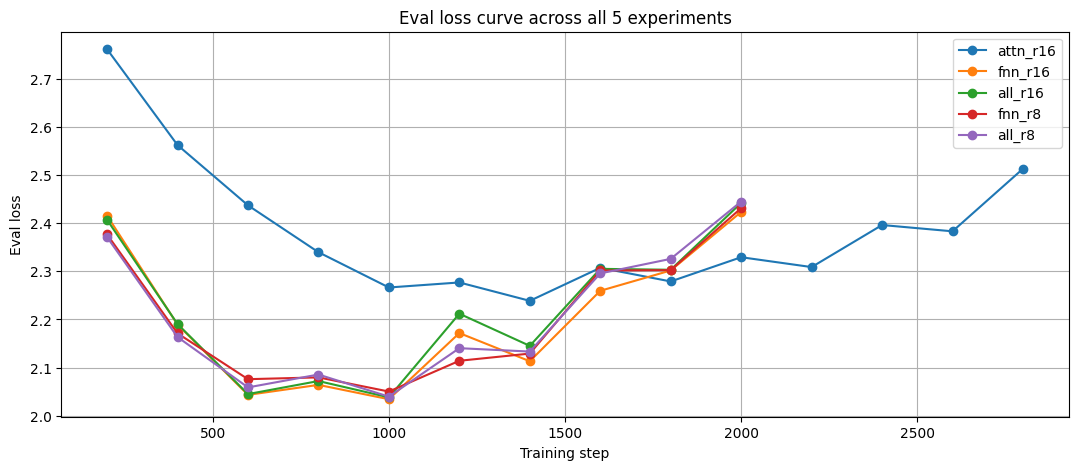

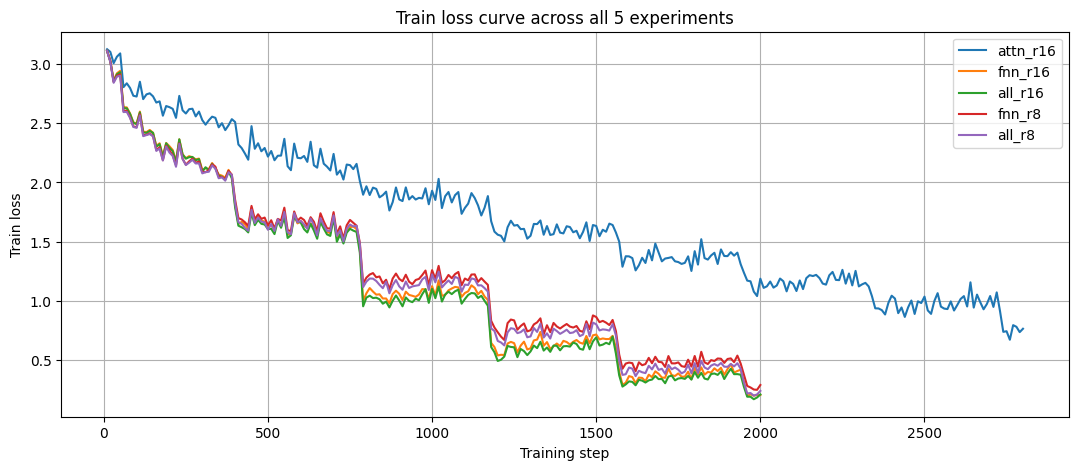


Prediction / Manual Analysis Files Found


,label,group,rank,experiment,file,path,type,num_predictions,BLEU,chrF
0,attn_r16,attn,16,qwen35_2b_alexandria_eg_only_context3_attn_20e...,manual_analysis_qwen35_2b_alexandria_eg_only_c...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.xlsx,NaN,NaN,NaN
1,attn_r16,attn,16,qwen35_2b_alexandria_eg_only_context3_attn_20e...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,6.284288,33.582584
2,fnn_r16,fnn/mlp,16,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,manual_analysis_qwen35_2b_alexandria_eg_only_c...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.xlsx,NaN,NaN,NaN
3,fnn_r16,fnn/mlp,16,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,8.669738,35.570982
4,all_r16,all,16,qwen35_2b_alexandria_eg_only_context3_all_grou...,manual_analysis_qwen35_2b_alexandria_eg_only_c...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.xlsx,NaN,NaN,NaN
5,all_r16,all,16,qwen35_2b_alexandria_eg_only_context3_all_grou...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,8.677226,36.446257
6,fnn_r8,fnn/mlp,8,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,manual_analysis_qwen35_2b_alexandria_eg_only_c...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.xlsx,NaN,NaN,NaN
7,fnn_r8,fnn/mlp,8,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,8.517086,36.005819
8,all_r8,all,8,qwen35_2b_alexandria_eg_only_context3_all_grou...,manual_analysis_qwen35_2b_alexandria_eg_only_c...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.xlsx,NaN,NaN,NaN
9,all_r8,all,8,qwen35_2b_alexandria_eg_only_context3_all_grou...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,8.196959,35.527687



Prediction Metrics from CSV Files


,label,group,rank,experiment,file,path,type,num_predictions,BLEU,chrF
0,all_r16,all,16,qwen35_2b_alexandria_eg_only_context3_all_grou...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,8.677226,36.446257
1,fnn_r8,fnn/mlp,8,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,8.517086,36.005819
2,fnn_r16,fnn/mlp,16,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,8.669738,35.570982
3,all_r8,all,8,qwen35_2b_alexandria_eg_only_context3_all_grou...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,8.196959,35.527687
4,attn_r16,attn,16,qwen35_2b_alexandria_eg_only_context3_attn_20e...,predictions_qwen35_2b_alexandria_eg_only_conte...,/content/drive/MyDrive/alexandria_qwen35_sft/p...,.csv,200.0,6.284288,33.582584



Best prediction file by BLEU:
  label = all_r16
  group = all
  rank  = 16
  file  = predictions_qwen35_2b_alexandria_eg_only_context3_all_group_20epochs.csv
  BLEU  = 8.6772

Best prediction file by chrF:
  label = all_r16
  group = all
  rank  = 16
  file  = predictions_qwen35_2b_alexandria_eg_only_context3_all_group_20epochs.csv
  chrF  = 36.4463

Final Compact Report


,label,group,rank,experiment,global_step,best_step,best_eval_loss,last_eval_loss,overfit_gap_last_minus_best,overfit_gap_percent,best_checkpoint_exists,last_checkpoint_exists,num_predictions,BLEU,chrF,file
0,all_r16,all,16,qwen35_2b_alexandria_eg_only_context3_all_grou...,2000,1000,2.037946,2.442135,0.404189,19.833145,False,True,200.0,8.677226,36.446257,predictions_qwen35_2b_alexandria_eg_only_conte...
1,all_r8,all,8,qwen35_2b_alexandria_eg_only_context3_all_grou...,2000,1000,2.039442,2.445004,0.405562,19.885942,True,True,200.0,8.196959,35.527687,predictions_qwen35_2b_alexandria_eg_only_conte...
2,attn_r16,attn,16,qwen35_2b_alexandria_eg_only_context3_attn_20e...,2800,1400,2.238575,2.513165,0.274590,12.266296,False,True,200.0,6.284288,33.582584,predictions_qwen35_2b_alexandria_eg_only_conte...
3,fnn_r16,fnn/mlp,16,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,2000,1000,2.034061,2.423385,0.389324,19.140230,False,True,200.0,8.669738,35.570982,predictions_qwen35_2b_alexandria_eg_only_conte...
4,fnn_r8,fnn/mlp,8,qwen35_2b_alexandria_eg_only_context3_fnn_grou...,2000,1000,2.050013,2.431273,0.381260,18.597931,True,True,200.0,8.517086,36.005819,predictions_qwen35_2b_alexandria_eg_only_conte...



Quick conclusion
Best checkpoint winner by eval_loss: fnn_r16
Last checkpoint winner by eval_loss: fnn_r16
Most stable / least overfitting by gap: attn_r16
Best generated translation by BLEU: all_r16
Best generated translation by chrF: all_r16

ATTN_R16:
  experiment = qwen35_2b_alexandria_eg_only_context3_attn_20epochs
  group = attn
  rank = 16
  global step = 2800
  best step = 1400
  best eval_loss = 2.2386
  last eval step = 2800
  last eval_loss = 2.5132
  overfit gap = 0.2746
  overfit gap percent = 12.27%
  Metric exists in trainer_state.json, but the actual model checkpoint is missing.

FNN_R16:
  experiment = qwen35_2b_alexandria_eg_only_context3_fnn_group_20epochs
  group = fnn/mlp
  rank = 16
  global step = 2000
  best step = 1000
  best eval_loss = 2.0341
  last eval step = 2000
  last eval_loss = 2.4234
  overfit gap = 0.3893
  overfit gap percent = 19.14%
  Metric exists in trainer_state.json, but the actual model checkpoint is missing.

ALL_R16:
  experiment = qwen35_

In [24]:
# ============================================================
# Compare ALL 5 current experiments from Drive
# Experiments:
# 1) ATTN r16
# 2) FNN/MLP r16
# 3) ALL r16
# 4) FNN/MLP r8
# 5) ALL r8
# ============================================================

from pathlib import Path
import json, re, os, math
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Drive paths
# ------------------------------------------------------------

try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

PROJECT_DIR = Path("/content/drive/MyDrive/alexandria_qwen35_sft")
RUNS_DIR    = PROJECT_DIR / "runs"
PRED_DIR    = PROJECT_DIR / "predictions"

print("PROJECT_DIR:", PROJECT_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("PRED_DIR:", PRED_DIR)

# ------------------------------------------------------------
# 2) Define the 5 experiments
# ------------------------------------------------------------

EXPERIMENTS = [
    {
        "label": "attn_r16",
        "group": "attn",
        "rank": 16,
        "exp_name": "qwen35_2b_alexandria_eg_only_context3_attn_20epochs",
    },
    {
        "label": "fnn_r16",
        "group": "fnn/mlp",
        "rank": 16,
        "exp_name": "qwen35_2b_alexandria_eg_only_context3_fnn_group_20epochs",
    },
    {
        "label": "all_r16",
        "group": "all",
        "rank": 16,
        "exp_name": "qwen35_2b_alexandria_eg_only_context3_all_group_20epochs",
    },
    {
        "label": "fnn_r8",
        "group": "fnn/mlp",
        "rank": 8,
        "exp_name": "qwen35_2b_alexandria_eg_only_context3_fnn_group_r8_10epochs",
    },
    {
        "label": "all_r8",
        "group": "all",
        "rank": 8,
        "exp_name": "qwen35_2b_alexandria_eg_only_context3_all_group_r8_10epochs",
    },
]

# ------------------------------------------------------------
# 3) Helpers
# ------------------------------------------------------------

def checkpoint_step(path: Path):
    m = re.search(r"checkpoint-(\d+)", str(path))
    return int(m.group(1)) if m else -1


def get_state_file(run_dir: Path):
    if run_dir is None or not run_dir.exists():
        return None, None

    state_files = list(run_dir.rglob("trainer_state.json"))
    if not state_files:
        return None, None

    best_file = None
    best_step = -1
    best_state = None

    for sf in state_files:
        try:
            state = json.loads(sf.read_text())
            step = int(state.get("global_step", checkpoint_step(sf)))
            if step > best_step:
                best_step = step
                best_file = sf
                best_state = state
        except Exception:
            continue

    return best_file, best_state


def extract_eval_history(state):
    rows = []
    for item in state.get("log_history", []):
        if "eval_loss" in item:
            rows.append({
                "step": int(item.get("step", -1)),
                "eval_loss": float(item["eval_loss"]),
                "eval_runtime": item.get("eval_runtime", None),
                "epoch": item.get("epoch", None),
            })

    if not rows:
        return pd.DataFrame(columns=["step", "eval_loss", "eval_runtime", "epoch"])

    return pd.DataFrame(rows).sort_values("step").reset_index(drop=True)


def extract_train_history(state):
    rows = []
    for item in state.get("log_history", []):
        if "loss" in item and "eval_loss" not in item:
            rows.append({
                "step": int(item.get("step", -1)),
                "train_loss": float(item["loss"]),
                "epoch": item.get("epoch", None),
            })

    if not rows:
        return pd.DataFrame(columns=["step", "train_loss", "epoch"])

    return pd.DataFrame(rows).sort_values("step").reset_index(drop=True)


def summarize_experiment(label, group, rank, exp_name):
    run_dir = RUNS_DIR / exp_name

    if not run_dir.exists():
        return {
            "label": label,
            "group": group,
            "rank": rank,
            "experiment": exp_name,
            "run_dir_exists": False,
            "error": "Run folder not found",
        }, None, None

    state_file, state = get_state_file(run_dir)

    if state is None:
        return {
            "label": label,
            "group": group,
            "rank": rank,
            "experiment": exp_name,
            "run_dir_exists": True,
            "error": "No trainer_state.json found",
        }, None, None

    eval_df = extract_eval_history(state)
    train_df = extract_train_history(state)

    ckpts = sorted(run_dir.glob("checkpoint-*"), key=checkpoint_step)
    last_ckpt = ckpts[-1] if ckpts else None
    last_ckpt_step = checkpoint_step(last_ckpt) if last_ckpt else int(state.get("global_step", -1))

    if len(eval_df) == 0:
        return {
            "label": label,
            "group": group,
            "rank": rank,
            "experiment": exp_name,
            "run_dir_exists": True,
            "state_file": str(state_file),
            "global_step": int(state.get("global_step", -1)),
            "error": "No eval_loss found in trainer_state.json",
        }, eval_df, train_df

    best_row = eval_df.loc[eval_df["eval_loss"].idxmin()]
    last_row = eval_df.iloc[-1]

    best_step = int(best_row["step"])
    last_eval_step = int(last_row["step"])

    expected_best_ckpt = run_dir / f"checkpoint-{best_step}"
    expected_last_ckpt = run_dir / f"checkpoint-{last_ckpt_step}"

    summary = {
        "label": label,
        "group": group,
        "rank": rank,
        "experiment": exp_name,
        "run_dir_exists": True,
        "state_file": str(state_file),
        "global_step": int(state.get("global_step", -1)),

        "best_step": best_step,
        "best_eval_loss": float(best_row["eval_loss"]),
        "best_epoch": best_row.get("epoch", None),
        "best_checkpoint_exists": expected_best_ckpt.exists(),
        "best_checkpoint_path": str(expected_best_ckpt),

        "last_checkpoint_step": last_ckpt_step,
        "last_eval_step": last_eval_step,
        "last_eval_loss": float(last_row["eval_loss"]),
        "last_epoch": last_row.get("epoch", None),
        "last_checkpoint_exists": expected_last_ckpt.exists(),
        "last_checkpoint_path": str(expected_last_ckpt),

        "overfit_gap_last_minus_best": float(last_row["eval_loss"] - best_row["eval_loss"]),
        "overfit_gap_percent": float(
            100 * (last_row["eval_loss"] - best_row["eval_loss"]) / best_row["eval_loss"]
        ),
    }

    return summary, eval_df, train_df


def find_prediction_files(exp_name):
    files = []
    if PRED_DIR.exists():
        files += list(PRED_DIR.glob(f"*{exp_name}*.csv"))
        files += list(PRED_DIR.glob(f"*{exp_name}*.xlsx"))
    return sorted(files)


def evaluate_prediction_file(path):
    if path.suffix.lower() != ".csv":
        return None

    try:
        df = pd.read_csv(path)
    except Exception:
        return None

    required = {"prediction", "reference_arabic"}
    if not required.issubset(df.columns):
        return None

    try:
        import sacrebleu
    except Exception:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"])
        import sacrebleu

    preds = df["prediction"].fillna("").astype(str).tolist()
    refs  = df["reference_arabic"].fillna("").astype(str).tolist()

    bleu = sacrebleu.corpus_bleu(preds, [refs]).score
    chrf = sacrebleu.corpus_chrf(preds, [refs]).score

    return {
        "file": path.name,
        "num_predictions": len(df),
        "BLEU": bleu,
        "chrF": chrf,
    }


def metric_winner(summary_dict, key, lower_is_better=True):
    valid = {
        label: s[key]
        for label, s in summary_dict.items()
        if ("error" not in s) and (key in s) and pd.notna(s[key])
    }

    if not valid:
        return None

    return min(valid, key=valid.get) if lower_is_better else max(valid, key=valid.get)


def prediction_metric_winner(pred_df, metric):
    if pred_df is None or len(pred_df) == 0 or metric not in pred_df.columns:
        return None

    valid = pred_df.dropna(subset=[metric])
    if len(valid) == 0:
        return None

    row = valid.loc[valid[metric].idxmax()]
    return row["label"]


# ------------------------------------------------------------
# 4) Summarize all experiments
# ------------------------------------------------------------

summaries = {}
eval_histories = {}
train_histories = {}

print("\nDetected experiments:")

for exp in EXPERIMENTS:
    run_dir = RUNS_DIR / exp["exp_name"]
    pred_files = find_prediction_files(exp["exp_name"])

    print(f"\n{exp['label']}")
    print("  run dir:", run_dir)
    print("  run exists:", run_dir.exists())
    print("  prediction files:", len(pred_files))

    summary, eval_df, train_df = summarize_experiment(
        label=exp["label"],
        group=exp["group"],
        rank=exp["rank"],
        exp_name=exp["exp_name"],
    )

    summaries[exp["label"]] = summary
    eval_histories[exp["label"]] = eval_df
    train_histories[exp["label"]] = train_df

summary_df = pd.DataFrame(list(summaries.values()))

print("\n==============================")
print("Best vs Last Checkpoint Summary")
print("==============================")
display(summary_df)

# ------------------------------------------------------------
# 5) Direct comparison by training/eval metrics
# ------------------------------------------------------------

valid_summaries = {
    label: s for label, s in summaries.items()
    if "error" not in s
}

if len(valid_summaries):
    comparison_rows = []

    for metric_name, key, lower_is_better in [
        ("Best eval loss", "best_eval_loss", True),
        ("Last eval loss", "last_eval_loss", True),
        ("Overfit gap: last - best", "overfit_gap_last_minus_best", True),
        ("Overfit gap percent", "overfit_gap_percent", True),
        ("Best step", "best_step", True),
    ]:
        row = {
            "comparison": metric_name,
            "winner": metric_winner(valid_summaries, key, lower_is_better=lower_is_better)
                      if metric_name != "Best step" else "not a winner metric",
        }

        for label, s in summaries.items():
            row[label] = s.get(key, None)

        comparison_rows.append(row)

    comparison_df = pd.DataFrame(comparison_rows)

    print("\n==============================")
    print("Direct Multi-Experiment Comparison")
    print("==============================")
    display(comparison_df)

# ------------------------------------------------------------
# 6) Plot eval loss curves
# ------------------------------------------------------------

plt.figure(figsize=(13, 5))

for label, eval_df in eval_histories.items():
    if eval_df is not None and len(eval_df):
        plt.plot(eval_df["step"], eval_df["eval_loss"], marker="o", label=f"{label}")

plt.xlabel("Training step")
plt.ylabel("Eval loss")
plt.title("Eval loss curve across all 5 experiments")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 7) Plot train loss curves
# ------------------------------------------------------------

plt.figure(figsize=(13, 5))

for label, train_df in train_histories.items():
    if train_df is not None and len(train_df):
        plt.plot(train_df["step"], train_df["train_loss"], label=f"{label}")

plt.xlabel("Training step")
plt.ylabel("Train loss")
plt.title("Train loss curve across all 5 experiments")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 8) Check prediction/manual-analysis files
# ------------------------------------------------------------

prediction_rows = []

for exp in EXPERIMENTS:
    label = exp["label"]
    exp_name = exp["exp_name"]
    files = find_prediction_files(exp_name)

    if not files:
        prediction_rows.append({
            "label": label,
            "group": exp["group"],
            "rank": exp["rank"],
            "experiment": exp_name,
            "file": "No prediction/manual-analysis files found",
        })
        continue

    for f in files:
        row = {
            "label": label,
            "group": exp["group"],
            "rank": exp["rank"],
            "experiment": exp_name,
            "file": f.name,
            "path": str(f),
            "type": f.suffix.lower(),
        }

        metrics = evaluate_prediction_file(f)
        if metrics:
            row.update(metrics)

        prediction_rows.append(row)

pred_files_df = pd.DataFrame(prediction_rows)

print("\n==============================")
print("Prediction / Manual Analysis Files Found")
print("==============================")
display(pred_files_df)

# ------------------------------------------------------------
# 9) Prediction metric comparison if available
# ------------------------------------------------------------

if "BLEU" in pred_files_df.columns:
    metric_rows = pred_files_df.dropna(subset=["BLEU", "chrF"], how="all").copy()
else:
    metric_rows = pd.DataFrame()

if len(metric_rows):
    print("\n==============================")
    print("Prediction Metrics from CSV Files")
    print("==============================")

    pred_metric_summary = (
        metric_rows
        .sort_values(["chrF", "BLEU"], ascending=[False, False])
        .reset_index(drop=True)
    )

    display(pred_metric_summary)

    best_bleu_row = pred_metric_summary.loc[pred_metric_summary["BLEU"].idxmax()]
    best_chrf_row = pred_metric_summary.loc[pred_metric_summary["chrF"].idxmax()]

    print("\nBest prediction file by BLEU:")
    print(f"  label = {best_bleu_row['label']}")
    print(f"  group = {best_bleu_row['group']}")
    print(f"  rank  = {best_bleu_row['rank']}")
    print(f"  file  = {best_bleu_row['file']}")
    print(f"  BLEU  = {best_bleu_row['BLEU']:.4f}")

    print("\nBest prediction file by chrF:")
    print(f"  label = {best_chrf_row['label']}")
    print(f"  group = {best_chrf_row['group']}")
    print(f"  rank  = {best_chrf_row['rank']}")
    print(f"  file  = {best_chrf_row['file']}")
    print(f"  chrF  = {best_chrf_row['chrF']:.4f}")

# ------------------------------------------------------------
# 10) Merge training summary with prediction metrics
# ------------------------------------------------------------

summary_compact_cols = [
    "label", "group", "rank", "experiment",
    "global_step", "best_step", "best_eval_loss",
    "last_eval_loss", "overfit_gap_last_minus_best",
    "overfit_gap_percent", "best_checkpoint_exists",
    "last_checkpoint_exists",
]

summary_compact = summary_df[
    [c for c in summary_compact_cols if c in summary_df.columns]
].copy()

if len(metric_rows):
    pred_compact = (
        metric_rows
        .sort_values(["label", "chrF", "BLEU"], ascending=[True, False, False])
        .groupby("label", as_index=False)
        .first()[["label", "num_predictions", "BLEU", "chrF", "file"]]
    )

    final_report = summary_compact.merge(pred_compact, on="label", how="outer")
else:
    final_report = summary_compact

print("\n==============================")
print("Final Compact Report")
print("==============================")
display(final_report)

# ------------------------------------------------------------
# 11) Simple text conclusion
# ------------------------------------------------------------

print("\n==============================")
print("Quick conclusion")
print("==============================")

if len(valid_summaries):
    best_eval_winner = metric_winner(valid_summaries, "best_eval_loss", lower_is_better=True)
    last_eval_winner = metric_winner(valid_summaries, "last_eval_loss", lower_is_better=True)
    stable_winner    = metric_winner(valid_summaries, "overfit_gap_last_minus_best", lower_is_better=True)

    print(f"Best checkpoint winner by eval_loss: {best_eval_winner}")
    print(f"Last checkpoint winner by eval_loss: {last_eval_winner}")
    print(f"Most stable / least overfitting by gap: {stable_winner}")

    if len(metric_rows):
        print(f"Best generated translation by BLEU: {prediction_metric_winner(metric_rows, 'BLEU')}")
        print(f"Best generated translation by chrF: {prediction_metric_winner(metric_rows, 'chrF')}")

    for label, s in summaries.items():
        print(f"\n{label.upper()}:")

        if "error" in s:
            print(f"  experiment = {s.get('experiment')}")
            print(f"  error = {s['error']}")
            continue

        print(f"  experiment = {s['experiment']}")
        print(f"  group = {s['group']}")
        print(f"  rank = {s['rank']}")
        print(f"  global step = {s['global_step']}")
        print(f"  best step = {s['best_step']}")
        print(f"  best eval_loss = {s['best_eval_loss']:.4f}")
        print(f"  last eval step = {s['last_eval_step']}")
        print(f"  last eval_loss = {s['last_eval_loss']:.4f}")
        print(f"  overfit gap = {s['overfit_gap_last_minus_best']:.4f}")
        print(f"  overfit gap percent = {s['overfit_gap_percent']:.2f}%")

        if not s["best_checkpoint_exists"]:
            print("  Warning: best checkpoint folder is not found.")
            print("  Metric exists in trainer_state.json, but the actual model checkpoint is missing.")

        if not s["last_checkpoint_exists"]:
            print("  Warning: last checkpoint folder is not found.")

    print("\nInterpretation guide:")
    print("- Best eval_loss = best validation point in training logs.")
    print("- best_checkpoint_exists tells whether you can actually reload that checkpoint.")
    print("- BLEU/chrF are from saved prediction CSV files, usually generated from the final adapter unless you explicitly generated from a checkpoint.")
    print("- chrF is usually more useful than BLEU for Arabic/dialectal Arabic.")
    print("- If r8 is close to r16 but has lower overfit gap, r8 is safer; if not, r16 remains stronger.")
else:
    print("No valid trainer_state.json summaries found. Check run folders above.")